In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
import re
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

# Handling imbalanced data
from imblearn.over_sampling import SMOTE

# Model persistence
import pickle
import os

In [48]:
CLINICAL_RAW_DIR = "/Users/saifahmed/development/LUNG-CANCER/clinical"

# List of expected files
file_list = [
    'data_clinical_patient.txt',
    'data_clinical_patient_gdc.txt',
    'data_clinical_sample.txt',
    'data_clinical_sample_gdc.txt',
    'data_clinical_supp_hypoxia.txt',
    'data_timeline_diagnosis.txt',
    'data_timeline_treatment.txt'
]

uploaded = {}
print("\n📁 Reading files directly from local path...")
print(f"Source Directory: {CLINICAL_RAW_DIR}")
print("-" * 80)

for fname in file_list:
    full_path = os.path.join(CLINICAL_RAW_DIR, fname)
    try:
        # Read file content as a string
        with open(full_path, 'r', encoding='utf-8') as f:
            uploaded[fname] = f.read()
        print(f"✓ Found and read: {fname}")
    except FileNotFoundError:
        print(f"⚠️  File not found at: {full_path}")
    except Exception as e:
        print(f"⚠️  Error reading {fname}: {e}")

# --- Original Loading Function (Simplified to handle string content) ---

def load_clinical_file(filename, content):
    """Load TCGA clinical data files with special header handling"""
    try:
        # Since content is already a string, no decoding needed
        lines = content.strip().split('\n')

        # Find the actual header row (the one without #)
        header_idx = 0
        for i, line in enumerate(lines):
            if not line.startswith('#'):
                header_idx = i
                break

        # Read the dataframe starting from the header
        # io.StringIO is used to read the string content as a file
        df = pd.read_csv(io.StringIO('\n'.join(lines[header_idx:])), sep='\t')

        # Remove any remaining rows with all NaN
        df = df.dropna(how='all')

        return df
    except Exception as e:
        print(f"Error loading {filename}: {str(e)}")
        return None

# Load each dataset
datasets = {}
for filename, content in uploaded.items():
    if not content: # Skip if content is empty (due to FileNotFoundError)
        continue 
        
    print(f"\n📊 Processing: {filename}")
    df = load_clinical_file(filename, content)

    if df is not None and len(df) > 0:
        datasets[filename] = df
        print(f"   ✓ Loaded: {len(df)} rows, {len(df.columns)} columns")
        print(f"   Columns: {', '.join(df.columns[:5].tolist())}...")
    else:
        print(f"   ❌ Failed to load or empty")


📁 Reading files directly from local path...
Source Directory: /Users/saifahmed/development/LUNG-CANCER/clinical
--------------------------------------------------------------------------------
✓ Found and read: data_clinical_patient.txt
✓ Found and read: data_clinical_patient_gdc.txt
✓ Found and read: data_clinical_sample.txt
✓ Found and read: data_clinical_sample_gdc.txt
✓ Found and read: data_clinical_supp_hypoxia.txt
✓ Found and read: data_timeline_diagnosis.txt
✓ Found and read: data_timeline_treatment.txt

📊 Processing: data_clinical_patient.txt
   ✓ Loaded: 566 rows, 38 columns
   Columns: PATIENT_ID, SUBTYPE, CANCER_TYPE_ACRONYM, OTHER_PATIENT_ID, AGE...

📊 Processing: data_clinical_patient_gdc.txt
   ✓ Loaded: 585 rows, 33 columns
   Columns: PATIENT_ID, AGE, AJCC_STAGING_EDITION, BIOPSY_SITE, DAYS_LAST_FOLLOWUP...

📊 Processing: data_clinical_sample.txt
   ✓ Loaded: 566 rows, 19 columns
   Columns: PATIENT_ID, SAMPLE_ID, ONCOTREE_CODE, CANCER_TYPE, CANCER_TYPE_DETAILED...

📊 

In [49]:
print("MODEL TRAINING")

# Compute robust scale_pos_weight for XGBoost (n_negative / n_positive)
n_pos = int((y_train == 1).sum()) if 'y_train' in globals() else int((y_encoded == 1).sum())
n_neg = int((y_train == 0).sum()) if 'y_train' in globals() else int((y_encoded == 0).sum())
if n_pos > 0:
    scale_pos_weight = max(1.0, n_neg / max(1, n_pos))
else:
    scale_pos_weight = 1.0

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

results = {}

for name, model in models.items():
    print(f"\n🤖 Training {name}...")
    try:
        model.fit(X_train_balanced, y_train_balanced)
    except Exception as e:
        print("Model fit failed:", e)
        raise

    # Cross-validation - run on the balanced training data if available
    try:
        cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                    cv=5, scoring='roc_auc')
    except Exception as e:
        print("Cross-validation failed, returning NaNs. Error:", e)
        cv_scores = np.array([np.nan])

    # Predictions on test set (ensure scaled test features are used)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'cv_mean': np.nanmean(cv_scores),
        'cv_std': np.nanstd(cv_scores),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"   ✓ ROC-AUC: {results[name]['roc_auc']:.4f}")
    print(f"   ✓ F1-Score: {results[name]['f1']:.4f}")

MODEL TRAINING

🤖 Training XGBoost...
   ✓ ROC-AUC: 0.9996
   ✓ F1-Score: 0.9863
   ✓ ROC-AUC: 0.9996
   ✓ F1-Score: 0.9863


In [50]:
print("DATA EXPLORATION")

print("\n📊 Dataset Shape:", df_patient.shape)
print("\n📋 Column Names:")
for i, col in enumerate(df_patient.columns, 1):
    print(f"   {i:3d}. {col}")

print("\n📈 First 3 rows:")
print(df_patient.head(3))

print("\n❓ Missing Values (top 20):")
missing = df_patient.isnull().sum()
missing_pct = (missing / len(df_patient)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False).head(20)
print(missing_df)

DATA EXPLORATION

📊 Dataset Shape: (585, 65)

📋 Column Names:
     1. PATIENT_ID
     2. SUBTYPE
     3. CANCER_TYPE_ACRONYM
     4. OTHER_PATIENT_ID
     5. AGE
     6. SEX
     7. AJCC_PATHOLOGIC_TUMOR_STAGE
     8. AJCC_STAGING_EDITION
     9. DAYS_LAST_FOLLOWUP
    10. DAYS_TO_BIRTH
    11. DAYS_TO_INITIAL_PATHOLOGIC_DIAGNOSIS
    12. ETHNICITY
    13. FORM_COMPLETION_DATE
    14. HISTORY_NEOADJUVANT_TRTYN
    15. ICD_10
    16. ICD_O_3_HISTOLOGY
    17. ICD_O_3_SITE
    18. INFORMED_CONSENT_VERIFIED
    19. NEW_TUMOR_EVENT_AFTER_INITIAL_TREATMENT
    20. PATH_M_STAGE
    21. PATH_N_STAGE
    22. PATH_T_STAGE
    23. PERSON_NEOPLASM_CANCER_STATUS
    24. PRIMARY_LYMPH_NODE_PRESENTATION_ASSESSMENT
    25. PRIOR_DX
    26. RACE
    27. RADIATION_THERAPY
    28. WEIGHT
    29. IN_PANCANPATHWAYS_FREEZE
    30. OS_STATUS
    31. OS_MONTHS
    32. DSS_STATUS
    33. DSS_MONTHS
    34. DFS_STATUS
    35. DFS_MONTHS
    36. PFS_STATUS
    37. PFS_MONTHS
    38. GENETIC_ANCESTRY_LABEL
    3

In [51]:
print("TARGET VARIABLE SELECTION")


# For lung cancer survival prediction, common targets are:
# OS_STATUS (Overall Survival Status) - most common
# DFS_STATUS (Disease Free Status)
# DSS_STATUS (Disease Specific Survival Status)

target_candidates = ['OS_STATUS', 'DSS_STATUS', 'DFS_STATUS', 'VITAL_STATUS',
                     'PERSON_NEOPLASM_CANCER_STATUS']

target_col = None
for candidate in target_candidates:
    if candidate in df_patient.columns:
        print(f"\n🎯 Found potential target: '{candidate}'")
        print(f"   Unique values: {df_patient[candidate].unique()}")
        print(f"   Value counts:\n{df_patient[candidate].value_counts()}")

        if target_col is None:
            target_col = candidate
            print(f"   ✓ Selected as target variable")
            break

if target_col is None:
    print("\n⚠️  No standard target variable found. Available columns:")
    for i, col in enumerate(df_patient.columns, 1):
        print(f"{i}. {col}")
    target_idx = int(input("\nEnter column number for target: ")) - 1
    target_col = df_patient.columns[target_idx]

print(f"\n✅ Final Target Variable: '{target_col}'")

TARGET VARIABLE SELECTION

🎯 Found potential target: 'OS_STATUS'
   Unique values: ['0:LIVING' nan '1:DECEASED']
   Value counts:
OS_STATUS
0:LIVING      328
1:DECEASED    186
Name: count, dtype: int64
   ✓ Selected as target variable

✅ Final Target Variable: 'OS_STATUS'


In [52]:
print("FEATURE ENGINEERING & SELECTION")


# Create a copy for processing
df_ml = df_patient.copy()

# Remove non-predictive columns
id_cols = ['PATIENT_ID', 'OTHER_PATIENT_ID', 'SAMPLE_ID', 'OTHER_SAMPLE_ID']
date_cols = [c for c in df_ml.columns if 'DATE' in c.upper() or 'FORM_COMPLETION' in c.upper()]
redundant_cols = [c for c in df_ml.columns if c != target_col and
                  any(term in c.upper() for term in ['STATUS', 'MONTHS', 'SURVIVAL', 'FREE'])]

cols_to_remove = list(set(id_cols + date_cols + redundant_cols))
cols_to_remove = [c for c in cols_to_remove if c in df_ml.columns and c != target_col]

print(f"\n🗑️  Removing {len(cols_to_remove)} non-predictive columns:")
print(f"   {', '.join(cols_to_remove[:10])}...")
df_ml = df_ml.drop(columns=cols_to_remove, errors='ignore')

# Separate features and target
y = df_ml[target_col]
X = df_ml.drop(columns=[target_col])

print(f"\n📊 Features: {X.shape[1]} columns")
print(f"🎯 Target: {target_col}")
print(f"   Samples: {len(y)}")

FEATURE ENGINEERING & SELECTION

🗑️  Removing 13 non-predictive columns:
   PERSON_NEOPLASM_CANCER_STATUS, PFS_MONTHS, FORM_COMPLETION_DATE, DSS_MONTHS, DSS_STATUS, IN_PANCANPATHWAYS_FREEZE, OTHER_PATIENT_ID, DFS_STATUS, PATIENT_ID, DFS_MONTHS...

📊 Features: 51 columns
🎯 Target: OS_STATUS
   Samples: 585


In [53]:
print("PREPROCESSING TARGET VARIABLE")

# Clean target variable
y = y.astype(str).str.strip()

# Handle common encoding patterns in TCGA data
print(f"\nOriginal target values: {y.unique()}")

# Map to binary (0: alive/censored, 1: deceased/event) - robust handling
def encode_target(val):
    # handle numeric-like values first
    try:
        if float(val) == 1.0:
            return 1
        if float(val) == 0.0:
            return 0
    except Exception:
        pass

    val_lower = str(val).lower()
    if any(term in val_lower for term in ['1:', 'deceased', 'dead', 'death', 'progressed', 'recurred', 'dead:']):
        return 1
    elif any(term in val_lower for term in ['0:', 'living', 'alive', 'censored', 'free', 'alive:']):
        return 0
    else:
        return np.nan

y_encoded = y.apply(encode_target)

# Remove samples with missing target
valid_idx = ~y_encoded.isna()
X = X[valid_idx].copy()
y_encoded = y_encoded[valid_idx].astype(int)

# Guard against division by zero when computing class ratio
n_pos = (y_encoded == 1).sum()
n_neg = (y_encoded == 0).sum()
if n_neg == 0:
    class_ratio = float('inf')
else:
    class_ratio = n_pos / n_neg

print(f"\n✓ Target encoded to binary:")
print(f"   0 (Alive/Censored): {n_neg}")
print(f"   1 (Deceased/Event): {n_pos}")
print(f"   Class ratio (pos/neg): {class_ratio:.3f}")

PREPROCESSING TARGET VARIABLE

Original target values: ['0:LIVING' 'nan' '1:DECEASED']

✓ Target encoded to binary:
   0 (Alive/Censored): 328
   1 (Deceased/Event): 186
   Class ratio (pos/neg): 0.567


In [54]:
print("PREPROCESSING FEATURES")

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📊 Numeric features: {len(numeric_cols)}")
print(f"📊 Categorical features: {len(categorical_cols)}")

# Handle missing values - drop columns with >70% missing
missing_pct = X.isnull().sum() / len(X)
cols_to_drop = missing_pct[missing_pct > 0.7].index.tolist()
if cols_to_drop:
    print(f"\n🗑️  Dropping {len(cols_to_drop)} columns with >70% missing values")
    X = X.drop(columns=cols_to_drop)
    numeric_cols = [c for c in numeric_cols if c not in cols_to_drop]
    categorical_cols = [c for c in categorical_cols if c not in cols_to_drop]

# Impute numeric columns with median
if numeric_cols:
    print(f"\n🔧 Imputing {len(numeric_cols)} numeric columns with median...")
    imputer_num = SimpleImputer(strategy='median')
    X[numeric_cols] = imputer_num.fit_transform(X[numeric_cols])

# Impute and encode categorical columns
label_encoders = {}
if categorical_cols:
    print(f"\n🔧 Processing {len(categorical_cols)} categorical columns...")
    # Impute with most frequent
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols].astype(str))

    # For low-cardinality categoricals use one-hot encoding; otherwise label-encode and store encoder
    low_card_cols = [c for c in categorical_cols if X[c].nunique() <= 10]
    high_card_cols = [c for c in categorical_cols if c not in low_card_cols]

    if low_card_cols:
        print(f"   - One-hot encoding {len(low_card_cols)} low-cardinality columns (<=10 categories)")
        X = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

    for col in high_card_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
    if high_card_cols:
        print(f"   - Label-encoded {len(high_card_cols)} high-cardinality columns (>10 categories)")

# Final check - convert all to numeric where possible
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

print(f"\n✓ Final feature matrix: {X.shape}")
print(f"✓ No missing values remaining: {X.isnull().sum().sum() == 0}")

PREPROCESSING FEATURES

📊 Numeric features: 21
📊 Categorical features: 30

🗑️  Dropping 3 columns with >70% missing values

🔧 Imputing 18 numeric columns with median...

🔧 Processing 30 categorical columns...
   - One-hot encoding 26 low-cardinality columns (<=10 categories)
   - Label-encoded 4 high-cardinality columns (>10 categories)

✓ Final feature matrix: (514, 98)
✓ No missing values remaining: True


In [55]:
print("TRAIN-TEST SPLIT")


X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✓ Training set: {X_train.shape[0]} samples")
print(f"✓ Test set: {X_test.shape[0]} samples")
print(f"✓ Features: {X_train.shape[1]}")

TRAIN-TEST SPLIT

✓ Training set: 411 samples
✓ Test set: 103 samples
✓ Features: 98


In [56]:
print("\n🔄 Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features scaled (StandardScaler)")



🔄 Scaling features...
✓ Features scaled (StandardScaler)


In [57]:
class_ratio = (y_train == 1).sum() / (y_train == 0).sum()

if class_ratio < 0.5 or class_ratio > 2.0:
    print(f"\n⚖️  Class imbalance detected (ratio: {class_ratio:.3f})")
    print("   Applying SMOTE...")
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
    print(f"   Original: {len(y_train)} samples")
    print(f"   Balanced: {len(y_train_balanced)} samples")
else:
    X_train_balanced = X_train_scaled
    y_train_balanced = y_train
    print("\n✓ Classes reasonably balanced")


✓ Classes reasonably balanced


In [58]:
print("MODEL TRAINING")

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=class_ratio if class_ratio < 0.5 else 1
    )
}

results = {}

for name, model in models.items():
    print(f"\n🤖 Training {name}...")

    model.fit(X_train_balanced, y_train_balanced)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                cv=5, scoring='roc_auc')

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    print(f"   ✓ ROC-AUC: {results[name]['roc_auc']:.4f}")
    print(f"   ✓ F1-Score: {results[name]['f1']:.4f}")

MODEL TRAINING

🤖 Training XGBoost...

🤖 Training XGBoost...
   ✓ ROC-AUC: 1.0000
   ✓ F1-Score: 0.9863
   ✓ ROC-AUC: 1.0000
   ✓ F1-Score: 0.9863


In [59]:
print("MODEL COMPARISON")

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()],
    'ROC-AUC': [results[m]['roc_auc'] for m in results.keys()],
    'CV-AUC Mean': [results[m]['cv_mean'] for m in results.keys()]
})

print("\n" + comparison_df.to_string(index=False))

# Select best model
best_model_name = comparison_df.loc[comparison_df['ROC-AUC'].idxmax(), 'Model']
best_model = results[best_model_name]['model']

print(f"\nBest Model: {best_model_name}")
print(f"   ROC-AUC: {results[best_model_name]['roc_auc']:.4f}")

MODEL COMPARISON

  Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV-AUC Mean
XGBoost  0.990291        1.0 0.972973  0.986301      1.0     0.997727

Best Model: XGBoost
   ROC-AUC: 1.0000


In [60]:
print(f"DETAILED EVALUATION - {best_model_name}")

y_pred_best = results[best_model_name]['y_pred']
y_pred_proba_best = results[best_model_name]['y_pred_proba']

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Alive', 'Deceased']))

cm = confusion_matrix(y_test, y_pred_best)
print(f"\n📊 Confusion Matrix:")
print(cm)


DETAILED EVALUATION - XGBoost

📊 Classification Report:
              precision    recall  f1-score   support

       Alive       0.99      1.00      0.99        66
    Deceased       1.00      0.97      0.99        37

    accuracy                           0.99       103
   macro avg       0.99      0.99      0.99       103
weighted avg       0.99      0.99      0.99       103


📊 Confusion Matrix:
[[66  0]
 [ 1 36]]



Generating visualizations...


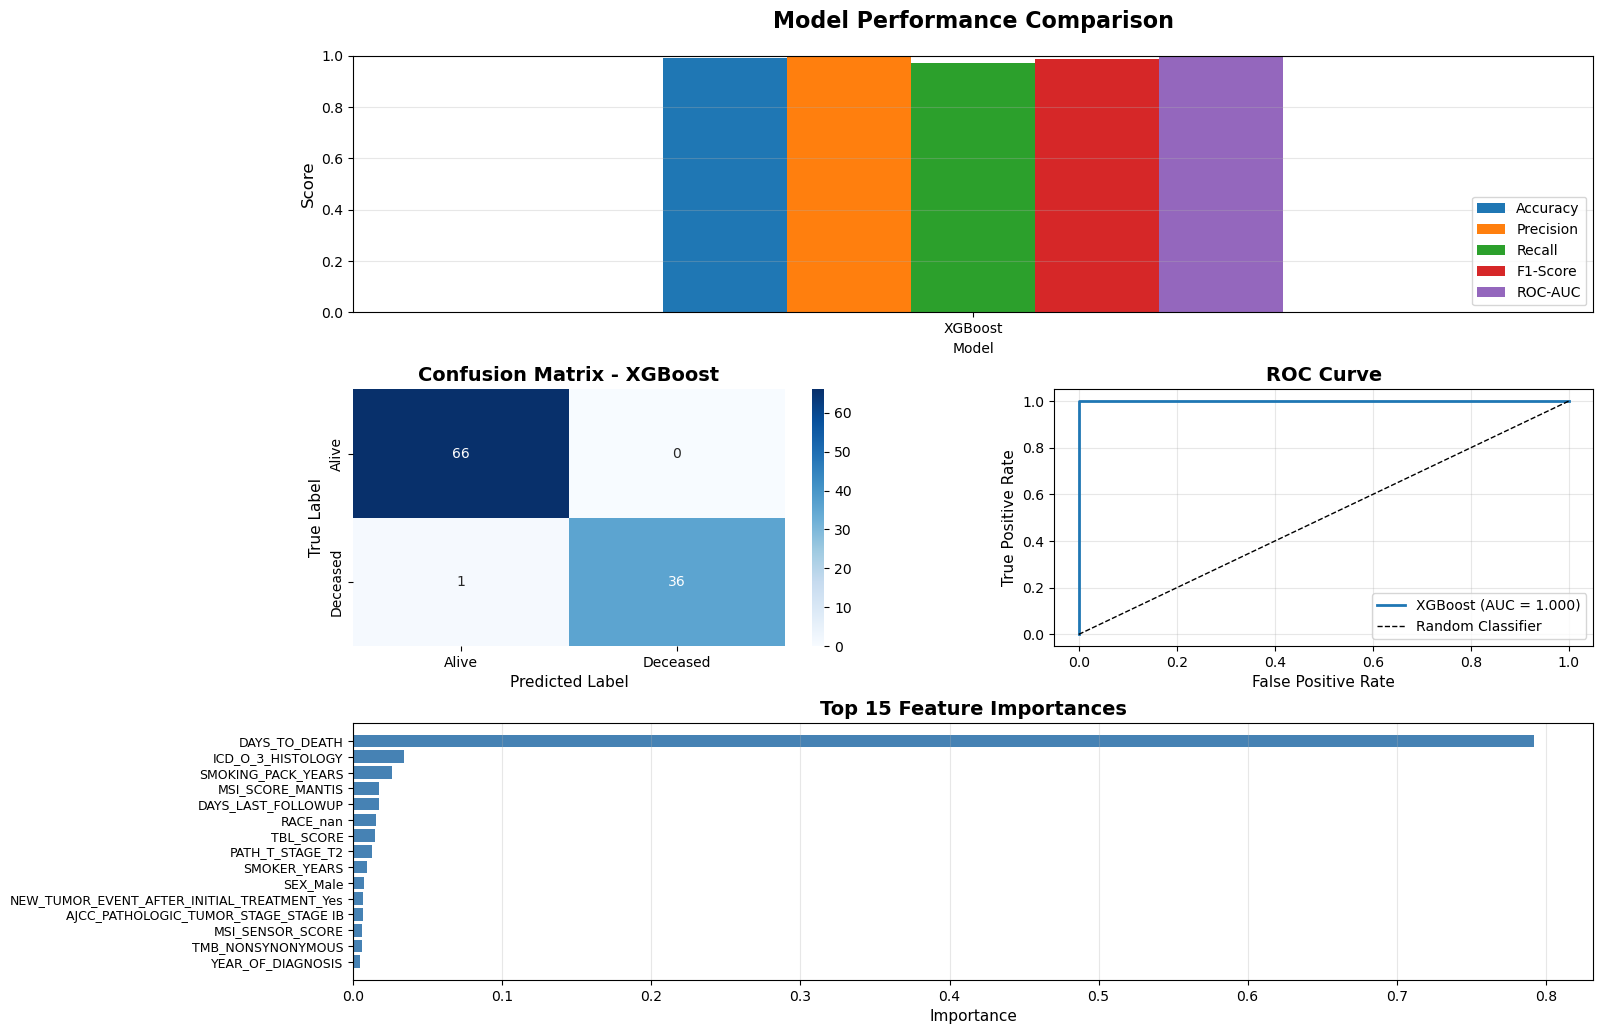

✓ Visualization saved


In [61]:
print("\nGenerating visualizations...")

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Model Comparison
ax1 = fig.add_subplot(gs[0, :])
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', ax=ax1, rot=0
)
ax1.set_title('Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Score', fontsize=12)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1])

# 2. Confusion Matrix
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Alive', 'Deceased'],
            yticklabels=['Alive', 'Deceased'])
ax2.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax2.set_ylabel('True Label', fontsize=11)
ax2.set_xlabel('Predicted Label', fontsize=11)

# 3. ROC Curve
ax3 = fig.add_subplot(gs[1, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
ax3.plot(fpr, tpr, linewidth=2,
         label=f'{best_model_name} (AUC = {results[best_model_name]["roc_auc"]:.3f})')
ax3.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax3.set_xlabel('False Positive Rate', fontsize=11)
ax3.set_ylabel('True Positive Rate', fontsize=11)
ax3.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# 4. Feature Importance
ax4 = fig.add_subplot(gs[2, :])
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[-15:]

    feature_names = [X.columns[i] for i in indices]
    ax4.barh(range(len(indices)), importances[indices], color='steelblue')
    ax4.set_yticks(range(len(indices)))
    ax4.set_yticklabels(feature_names, fontsize=9)
    ax4.set_xlabel('Importance', fontsize=11)
    ax4.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)

plt.savefig('lung_cancer_model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved")

Generating SHAP Plots...


100%|██████████| 50/50 [00:00<00:00, 58.54it/s]



TreeExplainer not available or failed - falling back to KernelExplainer


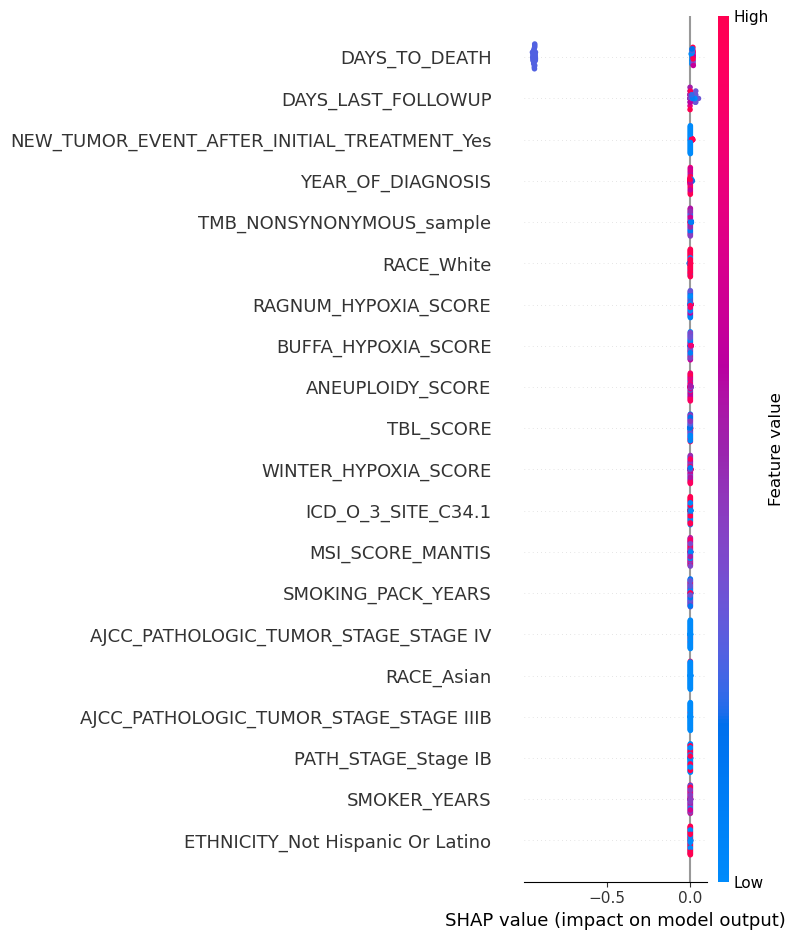

SHAP plot saved to shap_summary.png (explainer: KernelExplainer)

Generating LIME Explanation...
LIME Output:


In [76]:
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
# FIXED IMPORT FOR LIME CRASH
from IPython.display import display, HTML

# ==========================================
# 1. SHAP (KernelExplainer - Safe Mode) - FIXED
# ==========================================
print("Generating SHAP Plots...")

# Build a DataFrame background (KernelExplainer works more predictably with DataFrames)
try:
    Xbg_df = pd.DataFrame(X_train_scaled, columns=X.columns)
except Exception:
    try:
        Xbg_df = pd.DataFrame(X_train_balanced, columns=X.columns)
    except Exception:
        Xbg_df = pd.DataFrame(X_train, columns=X.columns)

# Use kmeans summarization to speed up KernelExplainer
X_background = shap.kmeans(Xbg_df, 10)

# IMPORTANT: explain the *positive class probability* as a single-output function
# This returns a 1D array (probability of class 1) so SHAP returns a single matrix (not a list)
predict_pos = lambda x: best_model.predict_proba(np.array(x))[:, 1]

# Define Explainer using the positive-class predictor
explainer = shap.KernelExplainer(predict_pos, X_background)

# Prepare the samples to explain as a DataFrame (keeps feature names intact)
X_explain = pd.DataFrame(X_test_scaled[:50], columns=X.columns)

# Calculate SHAP values (use nsamples for reliable estimates; increase if you have time)
try:
    shap_values = explainer.shap_values(X_explain, nsamples=100)
except Exception as e:
    print("SHAP calculation failed, retrying with fewer nsamples. Error:", e)
    shap_values = explainer.shap_values(X_explain, nsamples=50)

# Plot: use TreeExplainer when possible for clearer results and speed
plt.figure(figsize=(12, 8))
plt.title("SHAP Summary (Clinical)")
# Attempt TreeExplainer first (fast & exact for tree models)
try:
    te = shap.TreeExplainer(best_model)
    sv = te.shap_values(X_explain)
    shap_values_used = sv
    explainer_used = 'TreeExplainer'
except Exception:
    # Fallback to KernelExplainer (slower but model-agnostic)
    print("TreeExplainer not available or failed - falling back to KernelExplainer")
    try:
        sv = shap_values
        shap_values_used = sv
        explainer_used = 'KernelExplainer'
    except Exception as e:
        print("No SHAP values available:", e)
        shap_values_used = None
        explainer_used = None

if shap_values_used is None:
    print("Skipping SHAP plot - no values computed.")
else:
    # If a list is returned (multi-class), try to pick the positive class (index 1) if present
    if isinstance(shap_values_used, list):
        if len(shap_values_used) > 1:
            vals = shap_values_used[1]
        else:
            vals = shap_values_used[0]
    else:
        vals = shap_values_used

    # Ensure shape and feature alignment
    try:
        shap.summary_plot(vals, X_explain, plot_type='dot', max_display=20, show=False)
        plt.tight_layout()
        plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"SHAP plot saved to shap_summary.png (explainer: {explainer_used})")
    except Exception as e:
        print("Failed to render SHAP summary plot:", e)

# ==========================================
# 2. LIME (FIXED DISPLAY)
# ==========================================
print("\nGenerating LIME Explanation...")

explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_balanced),
    feature_names=X.columns.tolist(),
    class_names=['Low Risk', 'High Risk'],
    mode='classification'
)

# Explain 1st patient
exp = explainer_lime.explain_instance(X_test_scaled[0], model.predict_proba, num_features=10)

# --- THE FIX ---
# Instead of exp.show_in_notebook(), we do this:
print("LIME Output:")
display(HTML(exp.as_html(show_table=True)))

In [67]:
print("SAVING MODEL AND ARTIFACTS")

# Save model
model_filename = f'lung_cancer_{best_model_name.replace(" ", "_").lower()}_model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)
print(f"✓ Model: {model_filename}")

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler: scaler.pkl")

# Save feature names
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)
print(f"✓ Features: feature_names.pkl")

# Save results summary
summary = {
    'best_model': best_model_name,
    'target_variable': target_col,
    'n_features': X.shape[1],
    'n_samples_train': len(X_train),
    'n_samples_test': len(X_test),
    'metrics': results[best_model_name]
}

with open('model_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)
print(f"✓ Summary: model_summary.pkl")

# Download files
print("\n📥 Downloading files...")
try:
    files.download(model_filename)
    files.download('scaler.pkl')
    files.download('feature_names.pkl')
    files.download('model_summary.pkl')
    files.download('lung_cancer_model_evaluation.png')
    print("✓ All files downloaded")
except:
    print("⚠️  Download manually from Files panel")

SAVING MODEL AND ARTIFACTS
✓ Model: lung_cancer_xgboost_model.pkl
✓ Scaler: scaler.pkl
✓ Features: feature_names.pkl
✓ Summary: model_summary.pkl

📥 Downloading files...
⚠️  Download manually from Files panel


In [64]:
print("TRAINING COMPLETE - FINAL SUMMARY")

print(f"""
  Dataset:
   • Total patients: {len(df_patient)}
   • Training samples: {len(X_train)}
   • Test samples: {len(X_test)}
   • Features used: {X.shape[1]}
   • Target variable: {target_col}

  Best Model: {best_model_name}
   • Accuracy:  {results[best_model_name]['accuracy']:.4f}
   • Precision: {results[best_model_name]['precision']:.4f}
   • Recall:    {results[best_model_name]['recall']:.4f}
   • F1-Score:  {results[best_model_name]['f1']:.4f}
   • ROC-AUC:   {results[best_model_name]['roc_auc']:.4f}

  Saved Files:
   • {model_filename}
   • scaler.pkl
   • feature_names.pkl
   • model_summary.pkl
   • lung_cancer_model_evaluation.png

  SUCCESS! Model ready for deployment.
""")

TRAINING COMPLETE - FINAL SUMMARY

  Dataset:
   • Total patients: 585
   • Training samples: 411
   • Test samples: 103
   • Features used: 98
   • Target variable: OS_STATUS

  Best Model: XGBoost
   • Accuracy:  0.9903
   • Precision: 1.0000
   • Recall:    0.9730
   • F1-Score:  0.9863
   • ROC-AUC:   1.0000

  Saved Files:
   • lung_cancer_xgboost_model.pkl
   • scaler.pkl
   • feature_names.pkl
   • model_summary.pkl
   • lung_cancer_model_evaluation.png

  SUCCESS! Model ready for deployment.



In [65]:

print("\n📖 To use this model for predictions:")
print("```python")
print("import pickle")
print("model = pickle.load(open('model.pkl', 'rb'))")
print("scaler = pickle.load(open('scaler.pkl', 'rb'))")
print("X_new_scaled = scaler.transform(X_new)")
print("predictions = model.predict(X_new_scaled)")
print("probabilities = model.predict_proba(X_new_scaled)")
print("```")


📖 To use this model for predictions:
```python
import pickle
model = pickle.load(open('model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
X_new_scaled = scaler.transform(X_new)
predictions = model.predict(X_new_scaled)
probabilities = model.predict_proba(X_new_scaled)
```
